## Initialization

In [1]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision_cp
importlib.reload(collision_cp)
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [2]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 110 / e_mass      # now in a.u.
c6 = 1.9e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 200517.73350671504
C6 190000.0
beta (a0) 525.3927746085943
E_beta (K) 2.852507331186637e-06
tau_beta (s) 1.6824646316466855e-05


In [4]:
num_samples = 5000

# properties of resonant spectrum
rrkm = 0.25e-2     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos
print(mean_spacing)

# thermal properties
temp = 0.76         # in terms of E6
num_resonances = 400        # should be odd
rrkm = 2 * np.pi / mean_spacing  # rrkm in terms of tau
print(1 / (mean_spacing / 2 / np.pi))
print(rrkm)

0.00672985852658674
933.6281412688629
933.6281412688628


In [5]:
L = (temp / E_beta / c6) ** (1 / 6) 
print(L) # distance (in atomic units) when energy of potential is equal to temperature
print(L / beta)

8.73042048011514
0.01661694051011475


In [6]:
length = 2 # cutoff distance (in beta)

mean_x = 10
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)
print(mean_coupling_strength)
# find positive time delay

def get_spectrum():
    while True:
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
        min_positive = np.min(energy_GOE_mat[energy_GOE_mat > 0])
        max_negative = np.max(energy_GOE_mat[energy_GOE_mat < 0])

        f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
        time_delay = None
        break

        time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
        
        if time_delay > rrkm:
            break
    return energy_GOE_mat, W_mat, x_actual, time_delay

energy_GOE_mat, W_mat, x_actual, time_delay = get_spectrum()
print(time_delay)

0.08257585795250619
None


In [15]:
hbar = 1
std_k = np.sqrt(temp) / 10
std_x = 1 / std_k
x0 = 100
k0 = 0.5
print(std_k)
print(length / k0)

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

def reflected_wave(t, k, x, r):
    position = np.exp(-1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)


0.08717797887081347
4.0


(999,)


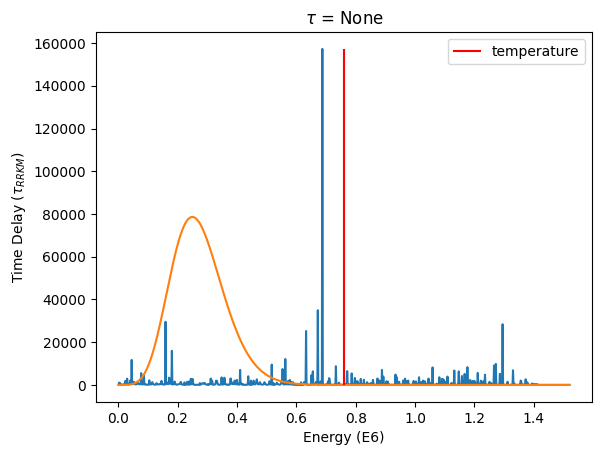

In [16]:
energy_grid = np.linspace(0, 2 * temp, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(time_delays.shape)
# time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(energy_grid.get(), max(time_delays.get() / np.abs(gaussian_envelope(k0)).get() ** 2 / 2) * np.abs(gaussian_envelope(np.sqrt(energy_grid))).get() ** 2)
plt.vlines(temp, min(time_delays.get()), max(time_delays.get()), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_{RRKM}$)")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.savefig("RRKM/spectrum.pdf")
plt.show()

In [90]:
import pickle 

data = {}

for momentum in np.arange(0.5, 1.1, 0.2):
    k0 = momentum.item()

    xs = np.linspace(-2800, 200, 3000)
    dx = xs[1] - xs[0]
    index = (xs > 100).argmax().item()

    ps = np.linspace(k0 - 6 * std_k, k0 + 6 * std_k, 2000)
    dp = ps[1] - ps[0]
    ps = ps.reshape((len(ps), 1))

    maxt = (200 / k0 / 2) * 30
    ts = np.linspace(0, maxt, 1000)
    dt = ts[1] - ts[0]
    time_min = 0
    # print(time_min)

    r1 = lambda k : np.exp(-1j * 2 * k * length) #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))
    psi1 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r1), axis=0)) * dp for t in ts])

    expected_delay = []
    total_percentage = []

    for i in range(100):
        energy_GOE_mat, W_mat, x_actual, time_delay = get_spectrum()

        r2 = lambda k : np.exp(-1j * 2 * k * length) * np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))
        psi2 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r2), axis=0)) * dp for t in ts])
        reflected2 = np.array([(np.sum(reflected_wave(t, ps, xs, r2), axis=0)) * dp for t in ts])
        if np.sum(np.abs(reflected2[len(ts) - 1][:index]) ** 2 * dx).get() > 0.05:
            print("Not All of Wave")

        # plt.plot(xs.get(), np.abs(reflected2[500]).get() ** 2)
        # plt.show()
        # print(np.sum(np.abs(reflected2[500]) ** 2 * dx))

        flux = []

        for time_index in range(time_min, len(ts)):
            # offset = (xs > xs[0] + 2 * k0 * ts[time_index]).argmax().item()
            flux.append(1 - np.sum(np.abs(reflected2[time_index][:index]) ** 2 * dx).get())

        flux = np.array(flux)
        total_percentage.append(flux[-1].item())

        pdf = flux.copy()
        for i in range(len(pdf) - 1, 0, -1):
            pdf[i] -= pdf[i - 1]
        expected_value = np.sum(pdf * ts[time_min:]).item()
        expected_delay.append(expected_value) 

        # plt.plot(ts[time_min:].get(), flux.get())
        # plt.plot(ts[time_min:].get(), pdf.get())
        # plt.show()
        # break

    save_dict = {"expected value": expected_delay, "percentage": total_percentage}
    data[k0] = save_dict
    # break
    
    with open("RRKM/sweeep.pkl", "wb") as f:
        pickle.dump(data, f)

# print(data)

6000.0


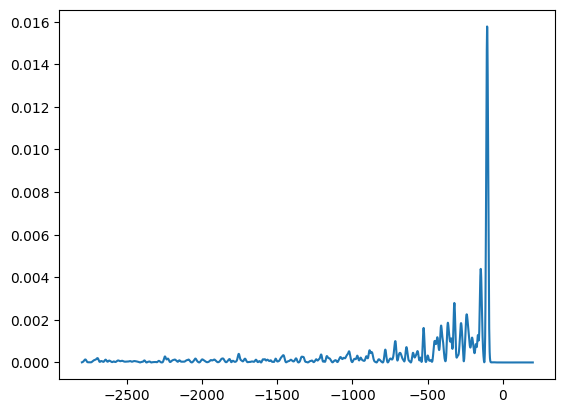

0.9435922596333975


In [89]:
time = 0
print(ts[len(ts) - 1])
plt.plot(xs.get(), np.abs(reflected2[time]).get() ** 2)
plt.show()
print(np.sum(np.abs(reflected2[time]) ** 2 * dx))

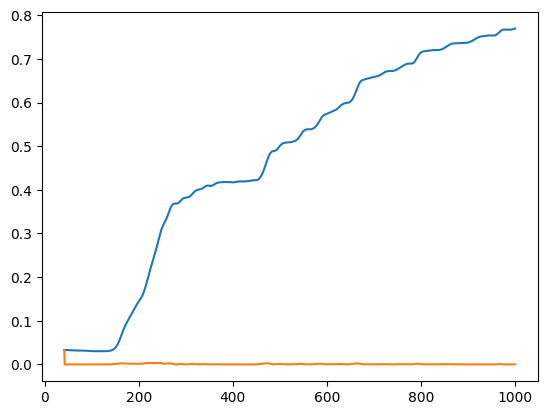

In [23]:
plt.plot(ts[time_min:].get(), flux.get())
plt.plot(ts[time_min:].get(), pdf.get())
plt.show()

In [22]:
print(data[0.5]["expected value"][:5])
print(data[0.5]["percentage"][:5])

[321.912822184433, 349.31936676782556, 326.6543035027735, 320.3093702705579, 313.5562378472622]
[0.718949059868003, 0.7474860296779702, 0.7821613176226028, 0.7739747681928335, 0.7364345664018971]


In [20]:
index = 100
print(xs[index])
print(dx)
time_min = 50
print(ts[time_min])
print(dt)

100.28612303290414
2.002861230329046
41.70141784820684
0.8340283569641368


0.9827263017865077
Expected 710.391561293437
Delay 510.391561293437


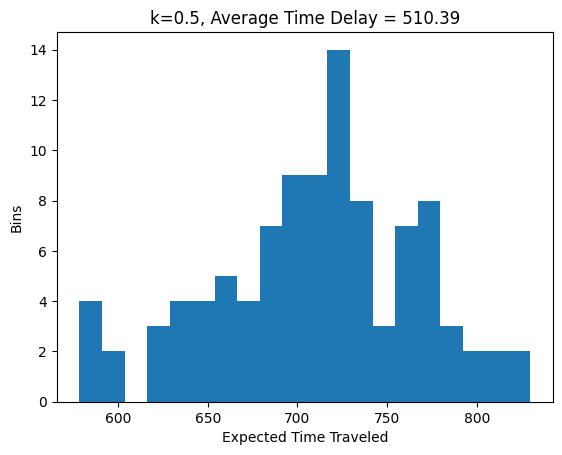

0.9754407460467425
Expected 540.9894780557753
Delay 398.1323351986324


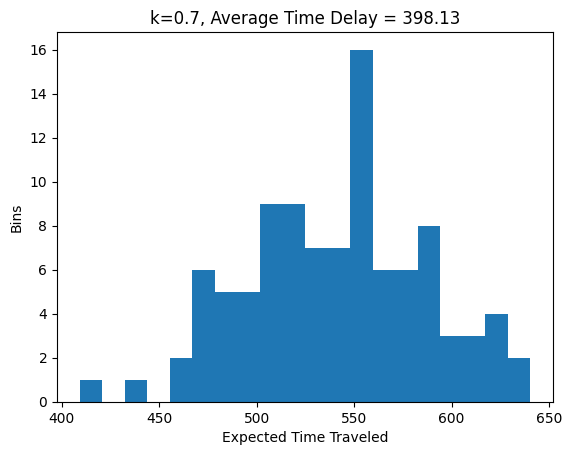

0.9636534391786815
Expected 377.12715083746923
Delay 266.01603972635814


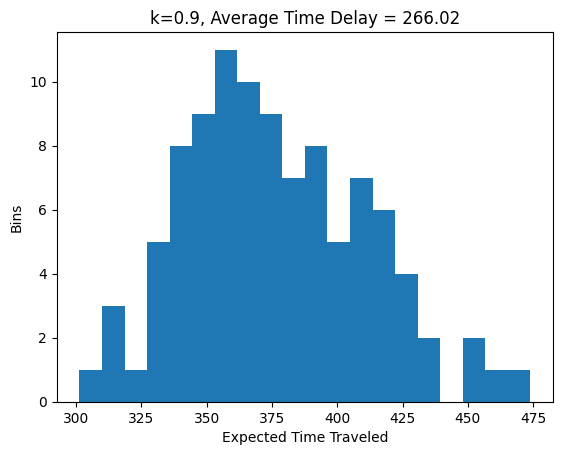

0.9686312382151063
Expected 206.93238899814264
Delay 116.02329808905174


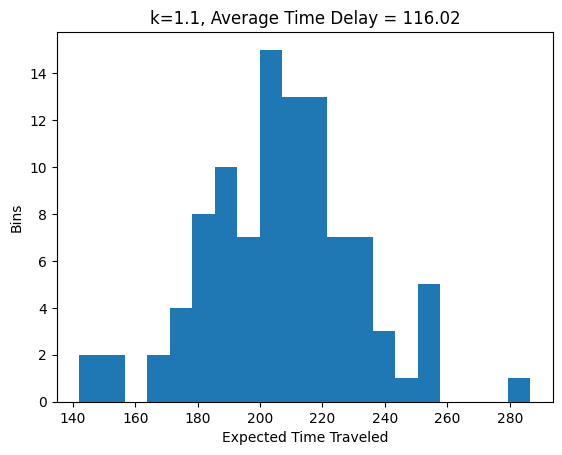

In [91]:
for key in data:
    expected_delay = np.array(data[key]["expected value"])
    total_percentage = data[key]["percentage"]
    print(min(total_percentage))

    print("Expected", np.mean(expected_delay))
    print("Delay", np.mean(expected_delay) - 100 / key)
    delay = np.mean(expected_delay) - 100 / key
    plt.hist(expected_delay.get(), bins=20)
    plt.xlabel("Expected Time Traveled")
    plt.ylabel("Bins")
    plt.title(f"k={key}, Average Time Delay = {round(delay.item(), 2)}")
    plt.savefig(f"RbCs/wavepacket/hist_{key}.pdf")
    plt.show()

## Together

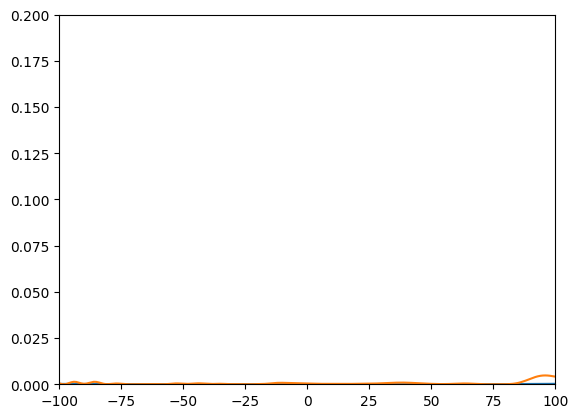

In [41]:
psis = [psi1, psi2]

import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
lines = []
for psi in psis:
    line = ax.plot(xs.get(), np.abs(psi[i]).get() ** 2)[0]
    lines.append(line)
ax.set(xlim=[-100, 100], ylim=[0, 0.2])

num = 1000
# line2 = ax.plot([mean1[0] for i in range(num)], [i / num for i in range(num)], color='red')[0]
# line3 = ax.plot([mean1_g0[0] for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 10
    for j in range(len(psis)):
        lines[j].set_ydata(np.abs(psis[j][i]).get() ** 2)
    # line2.set_xdata([mean1[i] for j in range(num)])
    # line3.set_xdata([mean1_g0[i] for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=20, interval=30)
ani